# Modeling — Logistic Regression & Random Forest

This notebook trains and evaluates two classifiers on the preprocessed Framingham data. We use AUC-ROC and F1-score as primary metrics given the class imbalance.

## 1. Imports

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score
)

sns.set_theme(style='whitegrid', palette='muted')

## 2. Load Preprocessed Data

Data was already scaled and SMOTE-balanced in the preprocessing notebook.

In [ ]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

# Split each set into features and the target column.
X_train, y_train = train.drop(columns=['TenYearCHD']), train['TenYearCHD']
X_val,   y_val   = val.drop(columns=['TenYearCHD']),   val['TenYearCHD']
X_test,  y_test  = test.drop(columns=['TenYearCHD']),  test['TenYearCHD']

print(f'Train : {X_train.shape}  |  Positive rate: {y_train.mean():.3f}')
print(f'Val   : {X_val.shape}   |  Positive rate: {y_val.mean():.3f}')
print(f'Test  : {X_test.shape}   |  Positive rate: {y_test.mean():.3f}')

Train : (5034, 15)  |  Positive rate: 0.500
Val   : (636, 15)   |  Positive rate: 0.153
Test  : (636, 15)   |  Positive rate: 0.151


## 3. Helper Functions

In [ ]:
def get_metrics(name, y_true, y_pred, y_prob):
    # Return a small set of model metrics for comparison.
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_true, y_prob)
    }

def plot_confusion(y_true, y_pred, title):
    # Show how many predictions were correct or wrong.
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No CHD', 'CHD'],
                yticklabels=['No CHD', 'CHD'])
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

def plot_roc(y_true, y_prob, label):
    # Show model discrimination using the ROC curve.
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.xlim([0, 1]); plt.ylim([0, 1.02])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {label}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## 4. Logistic Regression

`max_iter=1000` ensures convergence on scaled data. `class_weight=balanced` is omitted because we already balanced via SMOTE.

In [ ]:
# Train logistic regression on the training data.
lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Use the validation set to check how well the model works.
lr_pred_val  = lr.predict(X_val)
lr_prob_val  = lr.predict_proba(X_val)[:, 1]

print('=== Logistic Regression — Validation Set ===')
print(classification_report(y_val, lr_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

=== Logistic Regression — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.90      0.67      0.77       539
         CHD       0.24      0.60      0.35        97

    accuracy                           0.66       636
   macro avg       0.57      0.63      0.56       636
weighted avg       0.80      0.66      0.70       636



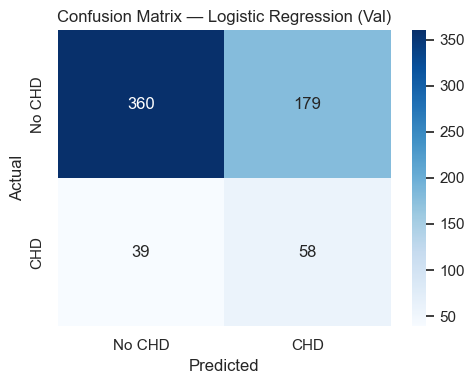

In [20]:
plot_confusion(y_val, lr_pred_val, 'Logistic Regression (Val)')

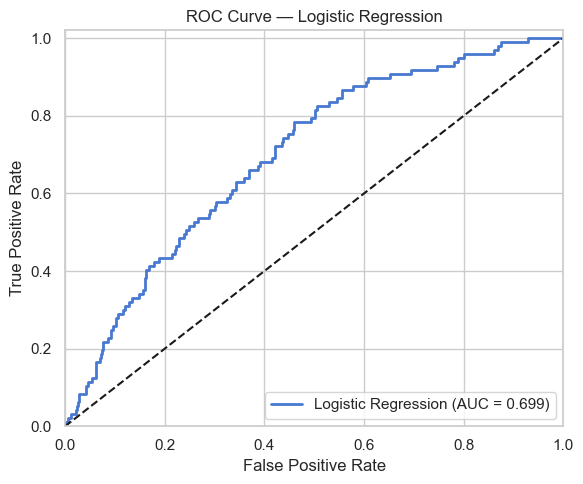

In [21]:
plot_roc(y_val, lr_prob_val, 'Logistic Regression')

### Feature Coefficients

Coefficients after scaling give a rough sense of each feature's direction and relative influence.

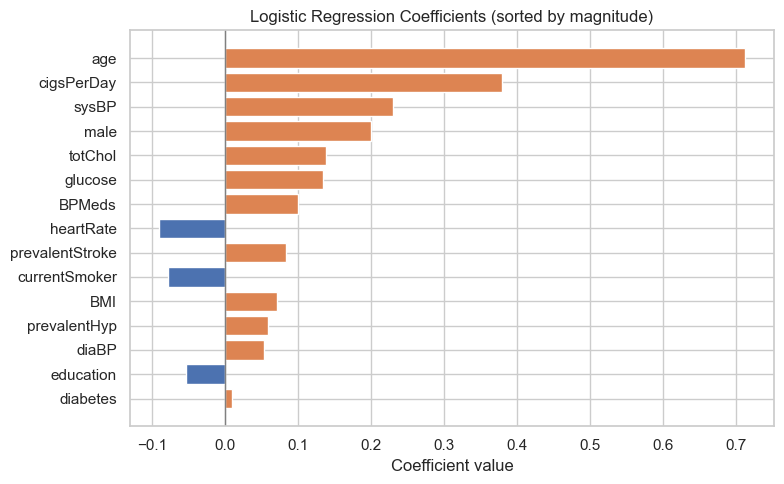

In [22]:
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='gray', lw=1)
plt.title('Logistic Regression Coefficients (sorted by magnitude)')
plt.xlabel('Coefficient value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Random Forest

In [ ]:
# Train a random forest on the training data.
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate the random forest on the validation data.
rf_pred_val = rf.predict(X_val)
rf_prob_val = rf.predict_proba(X_val)[:, 1]

print('=== Random Forest — Validation Set ===')
print(classification_report(y_val, rf_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

=== Random Forest — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.86      0.87      0.86       539
         CHD       0.21      0.19      0.20        97

    accuracy                           0.77       636
   macro avg       0.53      0.53      0.53       636
weighted avg       0.76      0.77      0.76       636



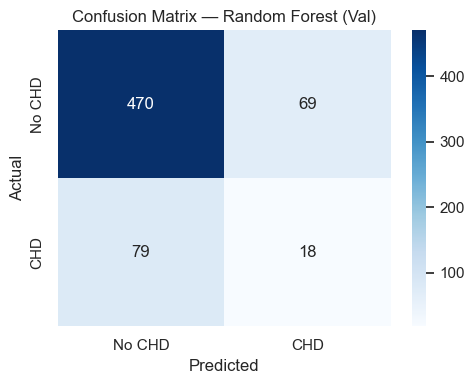

In [24]:
plot_confusion(y_val, rf_pred_val, 'Random Forest (Val)')

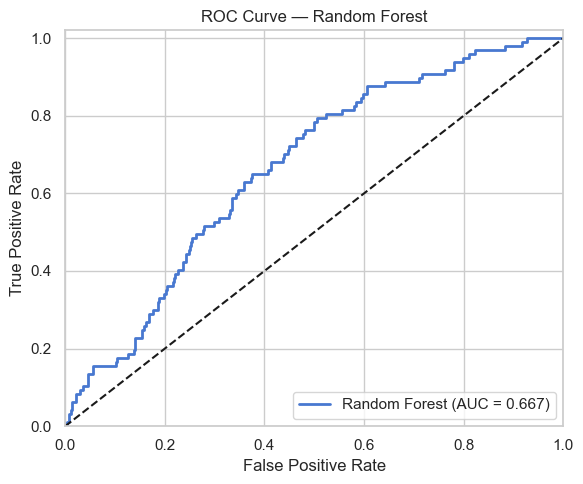

In [25]:
plot_roc(y_val, rf_prob_val, 'Random Forest')

### Feature Importances

Mean decrease in impurity across all trees.

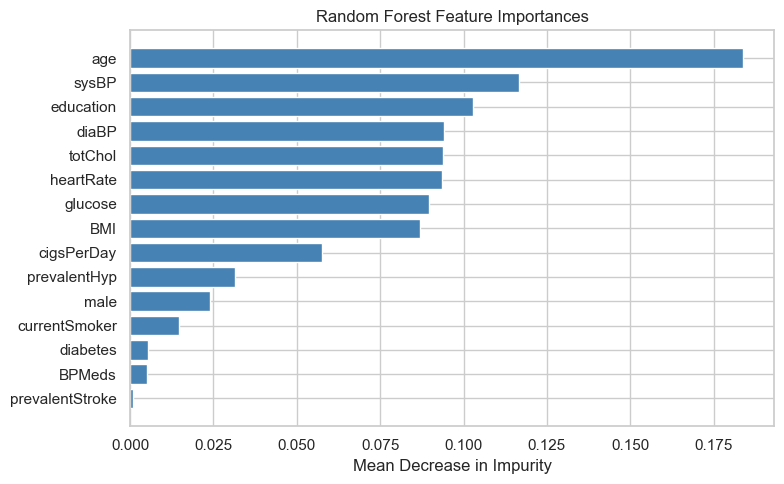

In [26]:
imp_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
plt.title('Random Forest Feature Importances')
plt.xlabel('Mean Decrease in Impurity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Model Comparison — Validation Set

In [ ]:
# Compare both models on the validation set before final testing.
results = [
    get_metrics('Logistic Regression', y_val, lr_pred_val, lr_prob_val),
    get_metrics('Random Forest',       y_val, rf_pred_val, rf_prob_val),
]
metrics_df = pd.DataFrame(results).set_index('Model')
metrics_df = metrics_df.round(4)
print(metrics_df.to_string())

                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.6572     0.2447  0.5979  0.3473  0.6988
Random Forest          0.7673     0.2069  0.1856  0.1957  0.6670


## 7. Final Evaluation — Test Set

The test set is touched **once**, after model selection is complete.

=== Final Test Set Results ===
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.6792     0.2545  0.5833  0.3544  0.6943
Random Forest          0.8097     0.3529  0.3125  0.3315  0.6680

=== Logistic Regression — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.90      0.70      0.79       540
         CHD       0.25      0.58      0.35        96

    accuracy                           0.68       636
   macro avg       0.58      0.64      0.57       636
weighted avg       0.81      0.68      0.72       636



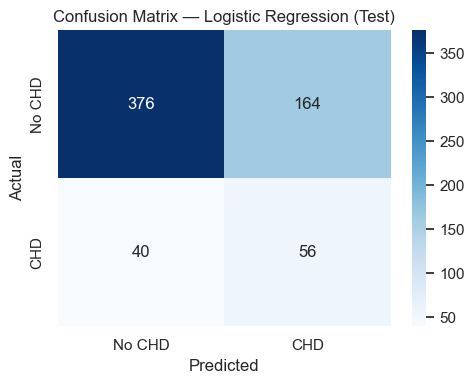

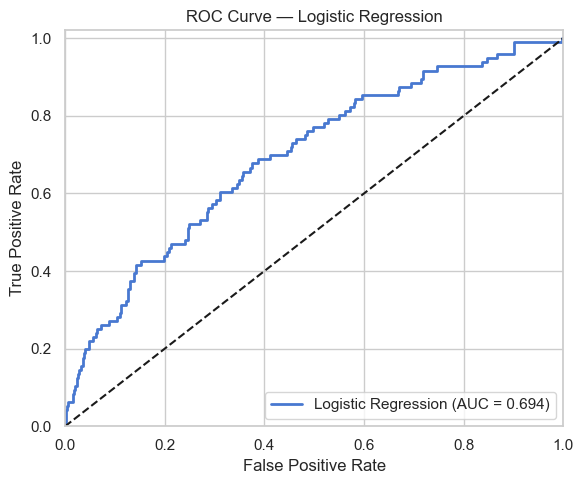


=== Random Forest — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.88      0.90      0.89       540
         CHD       0.35      0.31      0.33        96

    accuracy                           0.81       636
   macro avg       0.62      0.61      0.61       636
weighted avg       0.80      0.81      0.80       636



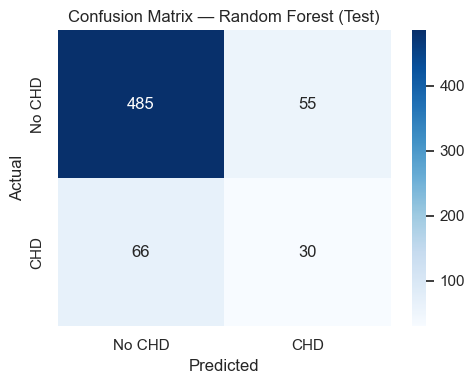

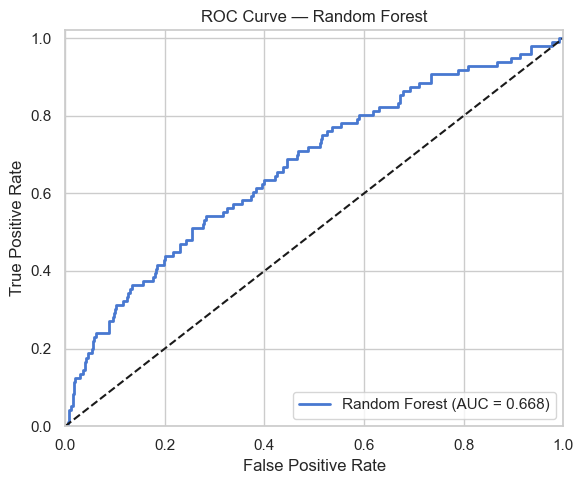

In [ ]:
# Evaluate both models on the test set after model selection.
test_results = [
    get_metrics('Logistic Regression', y_test, lr.predict(X_test), lr.predict_proba(X_test)[:, 1]),
    get_metrics('Random Forest',       y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1]),
]
test_df = pd.DataFrame(test_results).set_index('Model').round(4)
print('=== Final Test Set Results ===')
print(test_df.to_string())

# Show the full report and plots for each model on the test set.
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(f'\n=== {name} — Test Set ===')
    print(classification_report(y_test, pred, target_names=['No CHD', 'CHD'], zero_division=0))
    plot_confusion(y_test, pred, f'{name} (Test)')
    plot_roc(y_test, prob, name)

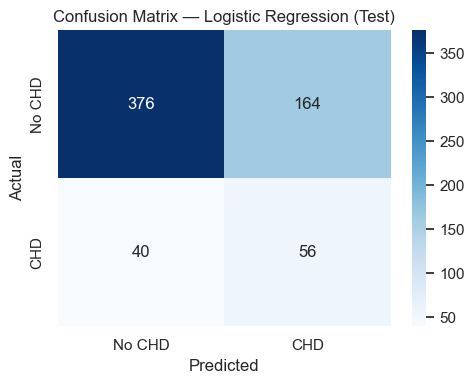

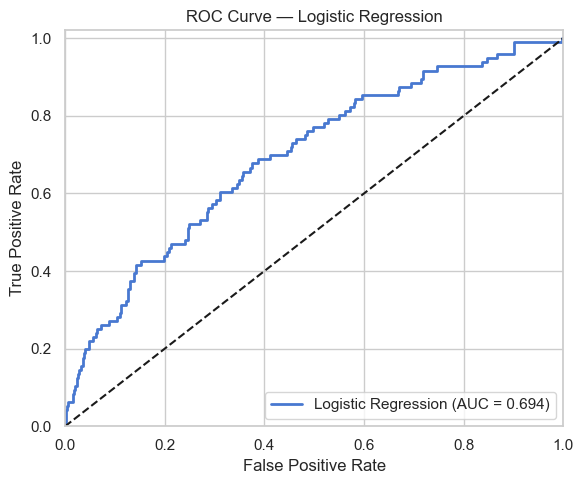

In [29]:
plot_confusion(y_test, test_pred, f'{best_name} (Test)')
plot_roc(y_test, test_prob, best_name)

## 8. ROC Curve Comparison

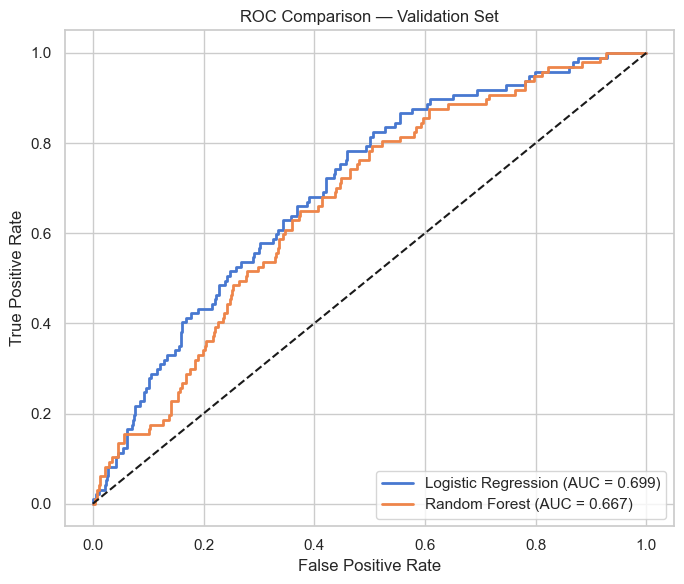

In [30]:
plt.figure(figsize=(7, 6))
for name, y_prob in [('Logistic Regression', lr_prob_val), ('Random Forest', rf_prob_val)]:
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison — Validation Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()